# 04 - Klasyfikacja: podium czy nie

Target: `podium` (pozycja koncowa <= 3). Cechy przedwyscigowe: pozycja startowa,
zespol, strata w kwalifikacjach do pole.

Model glowny: **regresja logistyczna** z `class_weight='balanced'` - przy ~1 sezonie
danych (malo wierszy, ~15% podium) jest najbardziej wiarygodna i interpretowalna.
Dla porownania dokladamy HistGradientBoosting - i pokazujemy liczbami, ze przy tej
ilosci danych przewaga drzew znika / sie przeucza.

Klasy sa **niezbalansowane**, wiec patrzymy na precision/recall, ROC-AUC i PR-AUC,
nie na samo accuracy. Walidacja: **StratifiedKFold** (malo danych -> CV zamiast
jednego splitu).

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)

dr = pd.read_parquet('../data/driver_race.parquet')
dr = dr.dropna(subset=['GridPosition']).reset_index(drop=True)

cat_cols = ['Team']
num_cols = ['GridPosition']

# dodaj quali_gap_s tylko jesli ma wystarczajaco duzo wartosci
if dr['quali_gap_s'].notna().sum() > 50:
    num_cols.append('quali_gap_s')
else:
    print('UWAGA: quali_gap_s pominiete (za duzo NaN) - model uzywa tylko GridPosition i Team')

features = cat_cols + num_cols

X = dr[features].copy()
y = dr['podium'].values
print('wierszy:', len(X), '| podiow:', int(y.sum()), f'({y.mean():.1%})')
print('cechy:', features)

UWAGA: quali_gap_s pominiete (za duzo NaN) - model uzywa tylko GridPosition i Team
wierszy: 479 | podiow: 72 (15.0%)
cechy: ['Team', 'GridPosition']


### Regresja logistyczna (model glowny)

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols),
])
logit = Pipeline([('pre', pre),
                  ('clf', LogisticRegression(class_weight='balanced',
                                             max_iter=1000))])

# predykcje out-of-fold (uczciwa ocena na malym zbiorze)
proba_logit = cross_val_predict(logit, X, y, cv=cv, method='predict_proba')[:, 1]
pred_logit = (proba_logit >= 0.5).astype(int)

print('LOGIT  ROC-AUC=%.3f  PR-AUC=%.3f' % (
    roc_auc_score(y, proba_logit), average_precision_score(y, proba_logit)))
print(classification_report(y, pred_logit, target_names=['no podium', 'podium']))

LOGIT  ROC-AUC=0.930  PR-AUC=0.715
              precision    recall  f1-score   support

   no podium       0.98      0.80      0.88       407
      podium       0.46      0.93      0.61        72

    accuracy                           0.82       479
   macro avg       0.72      0.87      0.75       479
weighted avg       0.91      0.82      0.84       479



### HistGradientBoosting (porownanie)

In [3]:
Xh = X.copy()
for c in cat_cols:
    Xh[c] = Xh[c].astype('category')
cat_mask = [c in cat_cols for c in features]

hgb = HistGradientBoostingClassifier(
    categorical_features=cat_mask, learning_rate=0.05,
    max_iter=200, l2_regularization=1.0,
    class_weight='balanced', random_state=42)

proba_hgb = cross_val_predict(hgb, Xh, y, cv=cv, method='predict_proba')[:, 1]
print('HGB    ROC-AUC=%.3f  PR-AUC=%.3f' % (
    roc_auc_score(y, proba_hgb), average_precision_score(y, proba_hgb)))
print('\n-> przy jednym sezonie logit jest zwykle rownie dobry lub lepszy,'
      ' i duzo bardziej interpretowalny.')

HGB    ROC-AUC=0.921  PR-AUC=0.641

-> przy jednym sezonie logit jest zwykle rownie dobry lub lepszy, i duzo bardziej interpretowalny.


### Macierz pomylek (logit)

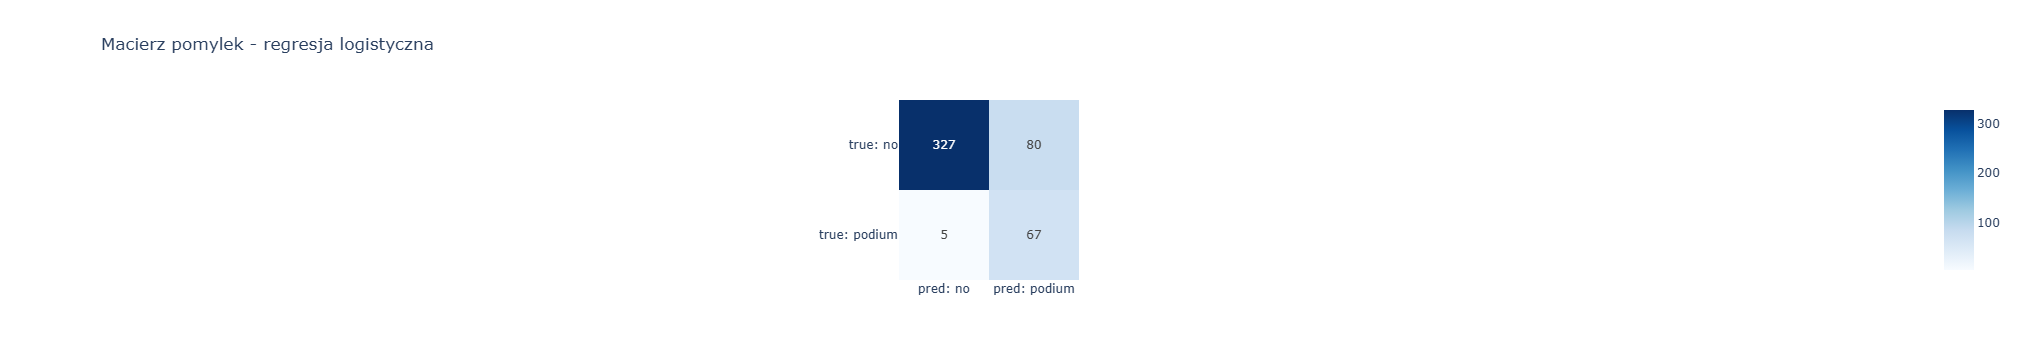

In [4]:
cm = confusion_matrix(y, pred_logit)
fig = px.imshow(cm, text_auto=True, color_continuous_scale='Blues',
                x=['pred: no', 'pred: podium'], y=['true: no', 'true: podium'],
                title='Macierz pomylek - regresja logistyczna')
fig.show()

### ROC i PR curve

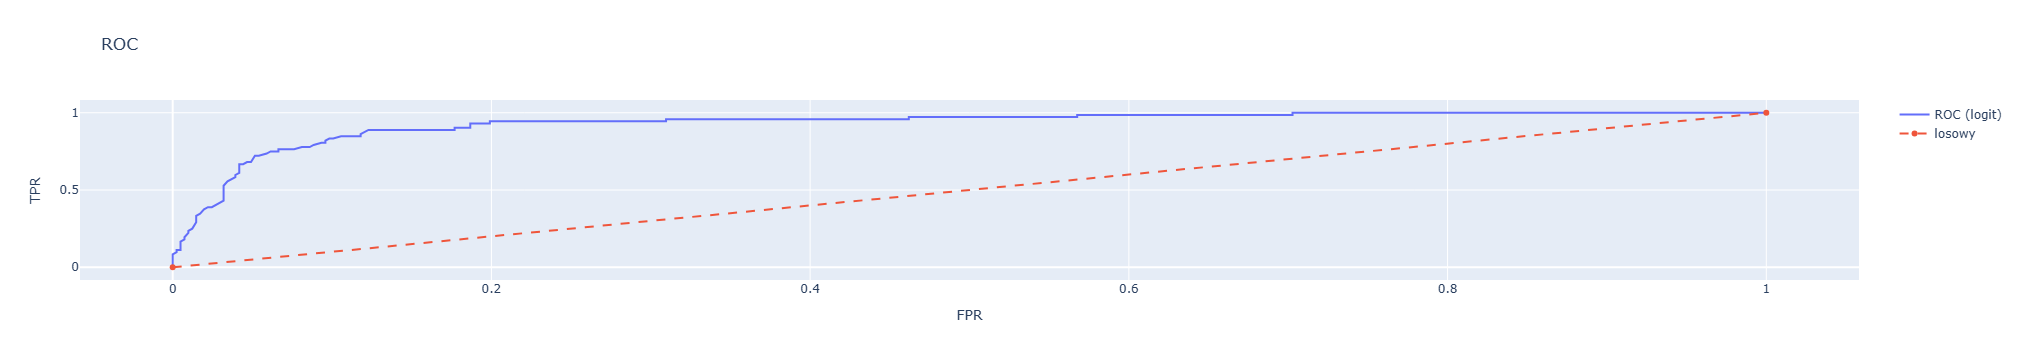

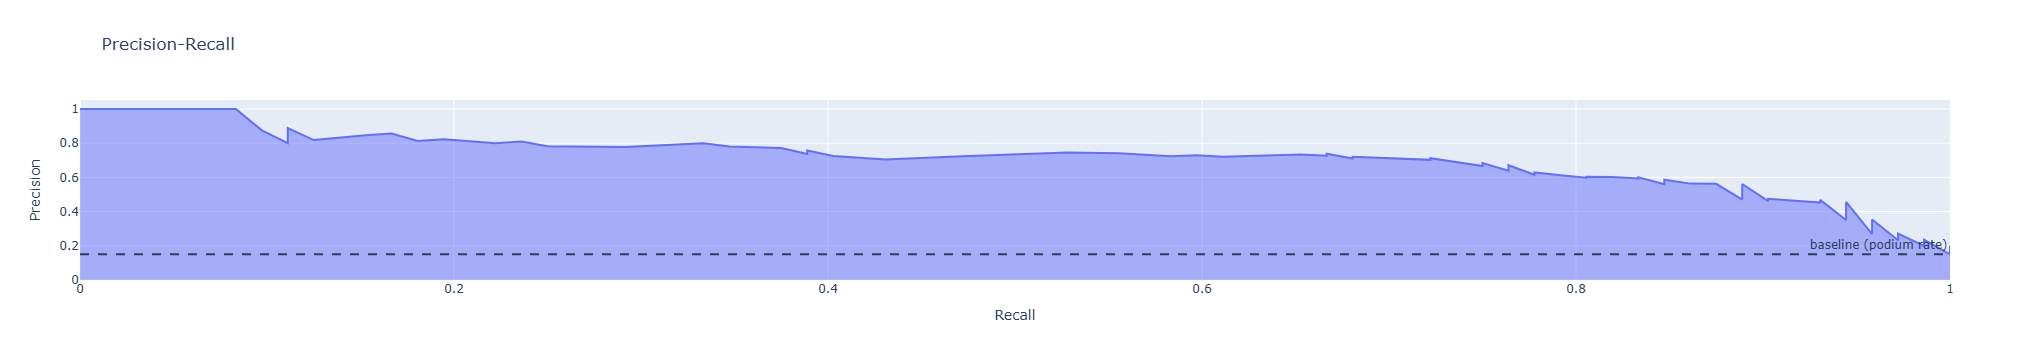

In [5]:
fpr, tpr, _ = roc_curve(y, proba_logit)
prec, rec, _ = precision_recall_curve(y, proba_logit)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, name='ROC (logit)'))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], line=dict(dash='dash'), name='losowy'))
fig.update_layout(title='ROC', xaxis_title='FPR', yaxis_title='TPR')
fig.show()

fig2 = px.area(x=rec, y=prec, title='Precision-Recall',
               labels={'x': 'Recall', 'y': 'Precision'})
fig2.add_hline(y=y.mean(), line_dash='dash',
               annotation_text='baseline (podium rate)')
fig2.show()

### Wspolczynniki logita (interpretacja)

In [6]:
logit.fit(X, y)
ohe = logit.named_steps['pre'].named_transformers_['cat']
names = list(ohe.get_feature_names_out(cat_cols)) + num_cols
coefs = logit.named_steps['clf'].coef_[0]
imp = pd.DataFrame({'feature': names, 'coef': coefs}).sort_values('coef')
fig = px.bar(imp, x='coef', y='feature', orientation='h',
             title='Wspolczynniki regresji logistycznej (log-odds)')
fig.show()

### Zapis pod analize bledow

In [7]:
out = dr.copy()
out['proba_logit'] = proba_logit
out['pred_logit'] = pred_logit
out['proba_hgb'] = proba_hgb
out.to_parquet('../data/clf_predictions.parquet', index=False)
print('zapisano ../data/clf_predictions.parquet', out.shape)

zapisano ../data/clf_predictions.parquet (479, 13)
